# Classification Phase 2 - Common Experimental Protocol

**Problem:** Classify the eventual outcome as `Dropout`, `Enrolled`, or `Graduate` using information available through the end of the second semester.

**Phase boundary:** This notebook establishes the Review 1 dataset audit, EDA, cleaning decisions, feature engineering, stratified split, and leakage-safe preprocessing contract. Training and comparing the five Part-A classifiers belongs to Phase 3.

**Primary source:** [UCI Predict Students' Dropout and Academic Success](https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success), DOI [10.24432/C5MC89](https://doi.org/10.24432/C5MC89), CC BY 4.0.

> **Team verification gate:** Generative AI assisted with notebook scaffolding. Before evaluation, the team must rerun every cell, verify each observation against the visible output, and rewrite any interpretation that does not match its own understanding.

## 1. Reproducible setup

In [1]:
from pathlib import Path
import platform

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from IPython.display import display

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", palette="colorblind")
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

def find_repo_root() -> Path:
    candidates = (Path.cwd(), *Path.cwd().parents)
    for candidate in candidates:
        if (candidate / "requirements.txt").is_file() and (candidate / "data").is_dir():
            return candidate
    raise FileNotFoundError("Run this notebook from inside the capstone repository.")

ROOT = find_repo_root()
print("Repository root detected.")
print(f"Python: {platform.python_version()}")
print(f"pandas: {pd.__version__} | scikit-learn: {sklearn.__version__}")

Repository root detected.
Python: 3.13.14
pandas: 3.0.6 | scikit-learn: 1.9.1


## 2. Data loading and prediction boundary

The source file uses a semicolon delimiter. Column whitespace is normalised immediately; this removes the source tab suffix from `Daytime/evening attendance` without changing any values. Because second-semester performance is included, the prediction point is explicitly the end of the first academic year, not enrollment time.

In [2]:
DATA_PATH = ROOT / "data" / "raw" / "student_outcomes" / "data.csv"
if not DATA_PATH.is_file():
    raise FileNotFoundError(
        "Student-outcome CSV is missing. Run: python data/download_datasets.py"
    )

raw = pd.read_csv(DATA_PATH, sep=";")
raw.columns = raw.columns.str.strip()
TARGET = "Target"
PREDICTORS = [column for column in raw.columns if column != TARGET]

print(f"Raw shape: {raw.shape}")
display(raw.head())

Raw shape: (4424, 37)


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0000,1,19,12,5,9,127.3000,1,0,0,1,1,0,20,0,0,0,0,0,0.0000,0,0,0,0,0,0.0000,0,10.8000,1.4000,1.7400,Dropout
1,1,15,1,9254,1,1,160.0000,1,1,3,3,3,142.5000,1,0,0,0,1,0,19,0,0,6,6,6,14.0000,0,0,6,6,6,13.6667,0,13.9000,-0.3000,0.7900,Graduate
2,1,1,5,9070,1,1,122.0000,1,37,37,9,9,124.8000,1,0,0,0,1,0,19,0,0,6,0,0,0.0000,0,0,6,0,0,0.0000,0,10.8000,1.4000,1.7400,Dropout
3,1,17,2,9773,1,1,122.0000,1,38,37,5,3,119.6000,1,0,0,1,0,0,20,0,0,6,8,6,13.4286,0,0,6,10,5,12.4000,0,9.4000,-0.8000,-3.1200,Graduate
4,2,39,1,8014,0,1,100.0000,1,37,38,9,9,141.5000,0,0,0,1,0,0,45,0,0,6,9,5,12.3333,0,0,6,6,6,13.0000,0,13.9000,-0.3000,0.7900,Graduate


**Observation:** The table contains 4,424 students, 36 predictors, and one three-class target. There is no free-text identifier or direct student ID. Integer codes such as `Course` and `Application mode` represent categories rather than numeric magnitudes and must not be standardised as continuous measurements.

## 3. Dataset audit

In [3]:
audit = pd.DataFrame(
    {
        "dtype": raw.dtypes.astype(str),
        "missing": raw.isna().sum(),
        "unique": raw.nunique(dropna=False),
    }
)
display(audit)
print(f"Missing values: {int(raw.isna().sum().sum())}")
print(f"Exact duplicate rows: {int(raw.duplicated().sum())}")

class_counts = raw[TARGET].value_counts().reindex(["Dropout", "Enrolled", "Graduate"])
class_audit = pd.DataFrame(
    {"rows": class_counts, "share_pct": 100 * class_counts / len(raw)}
)
display(class_audit)

,dtype,missing,unique
Marital status,int64,0,6
Application mode,int64,0,18
Application order,int64,0,8
Course,int64,0,17
Daytime/evening attendance,int64,0,2
Previous qualification,int64,0,17
Previous qualification (grade),float64,0,101
Nacionality,int64,0,21
Mother's qualification,int64,0,29
Father's qualification,int64,0,34


Missing values: 0
Exact duplicate rows: 0


,rows,share_pct
Target,,
Dropout,1421,32.1203
Enrolled,794,17.9476
Graduate,2209,49.9322


**Observation:** The source has no missing values and no exact duplicate rows. The target is imbalanced: `Graduate` is the largest class, while `Enrolled` is the smallest. Phase 3 must therefore report macro F1 and per-class recall alongside weighted metrics so performance on `Enrolled` is not hidden.

## 4. Target and predictor distributions

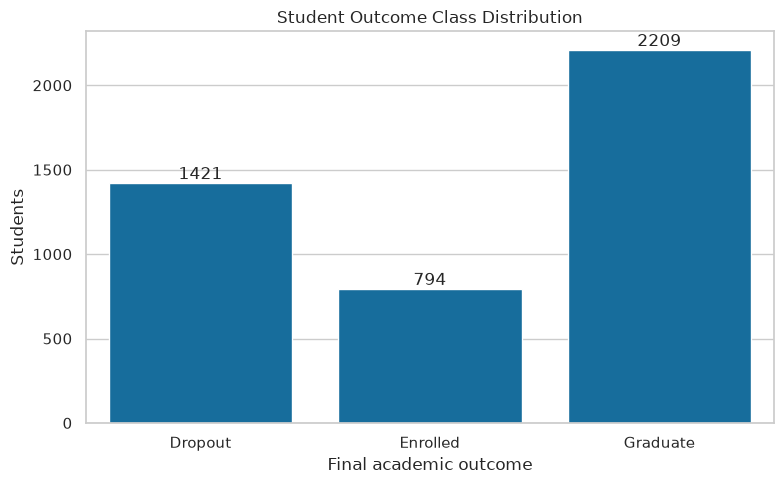

In [4]:
plt.figure(figsize=(8, 5))
axis = sns.countplot(data=raw, x=TARGET, order=["Dropout", "Enrolled", "Graduate"])
axis.set_title("Student Outcome Class Distribution")
axis.set_xlabel("Final academic outcome")
axis.set_ylabel("Students")
for container in axis.containers:
    axis.bar_label(container)
plt.tight_layout()
plt.show()

**Observation:** Nearly half of the records are `Graduate`, and `Enrolled` has only 794 observations. A stratified split is necessary to preserve these proportions, but stratification alone does not solve the difficulty of the minority class.

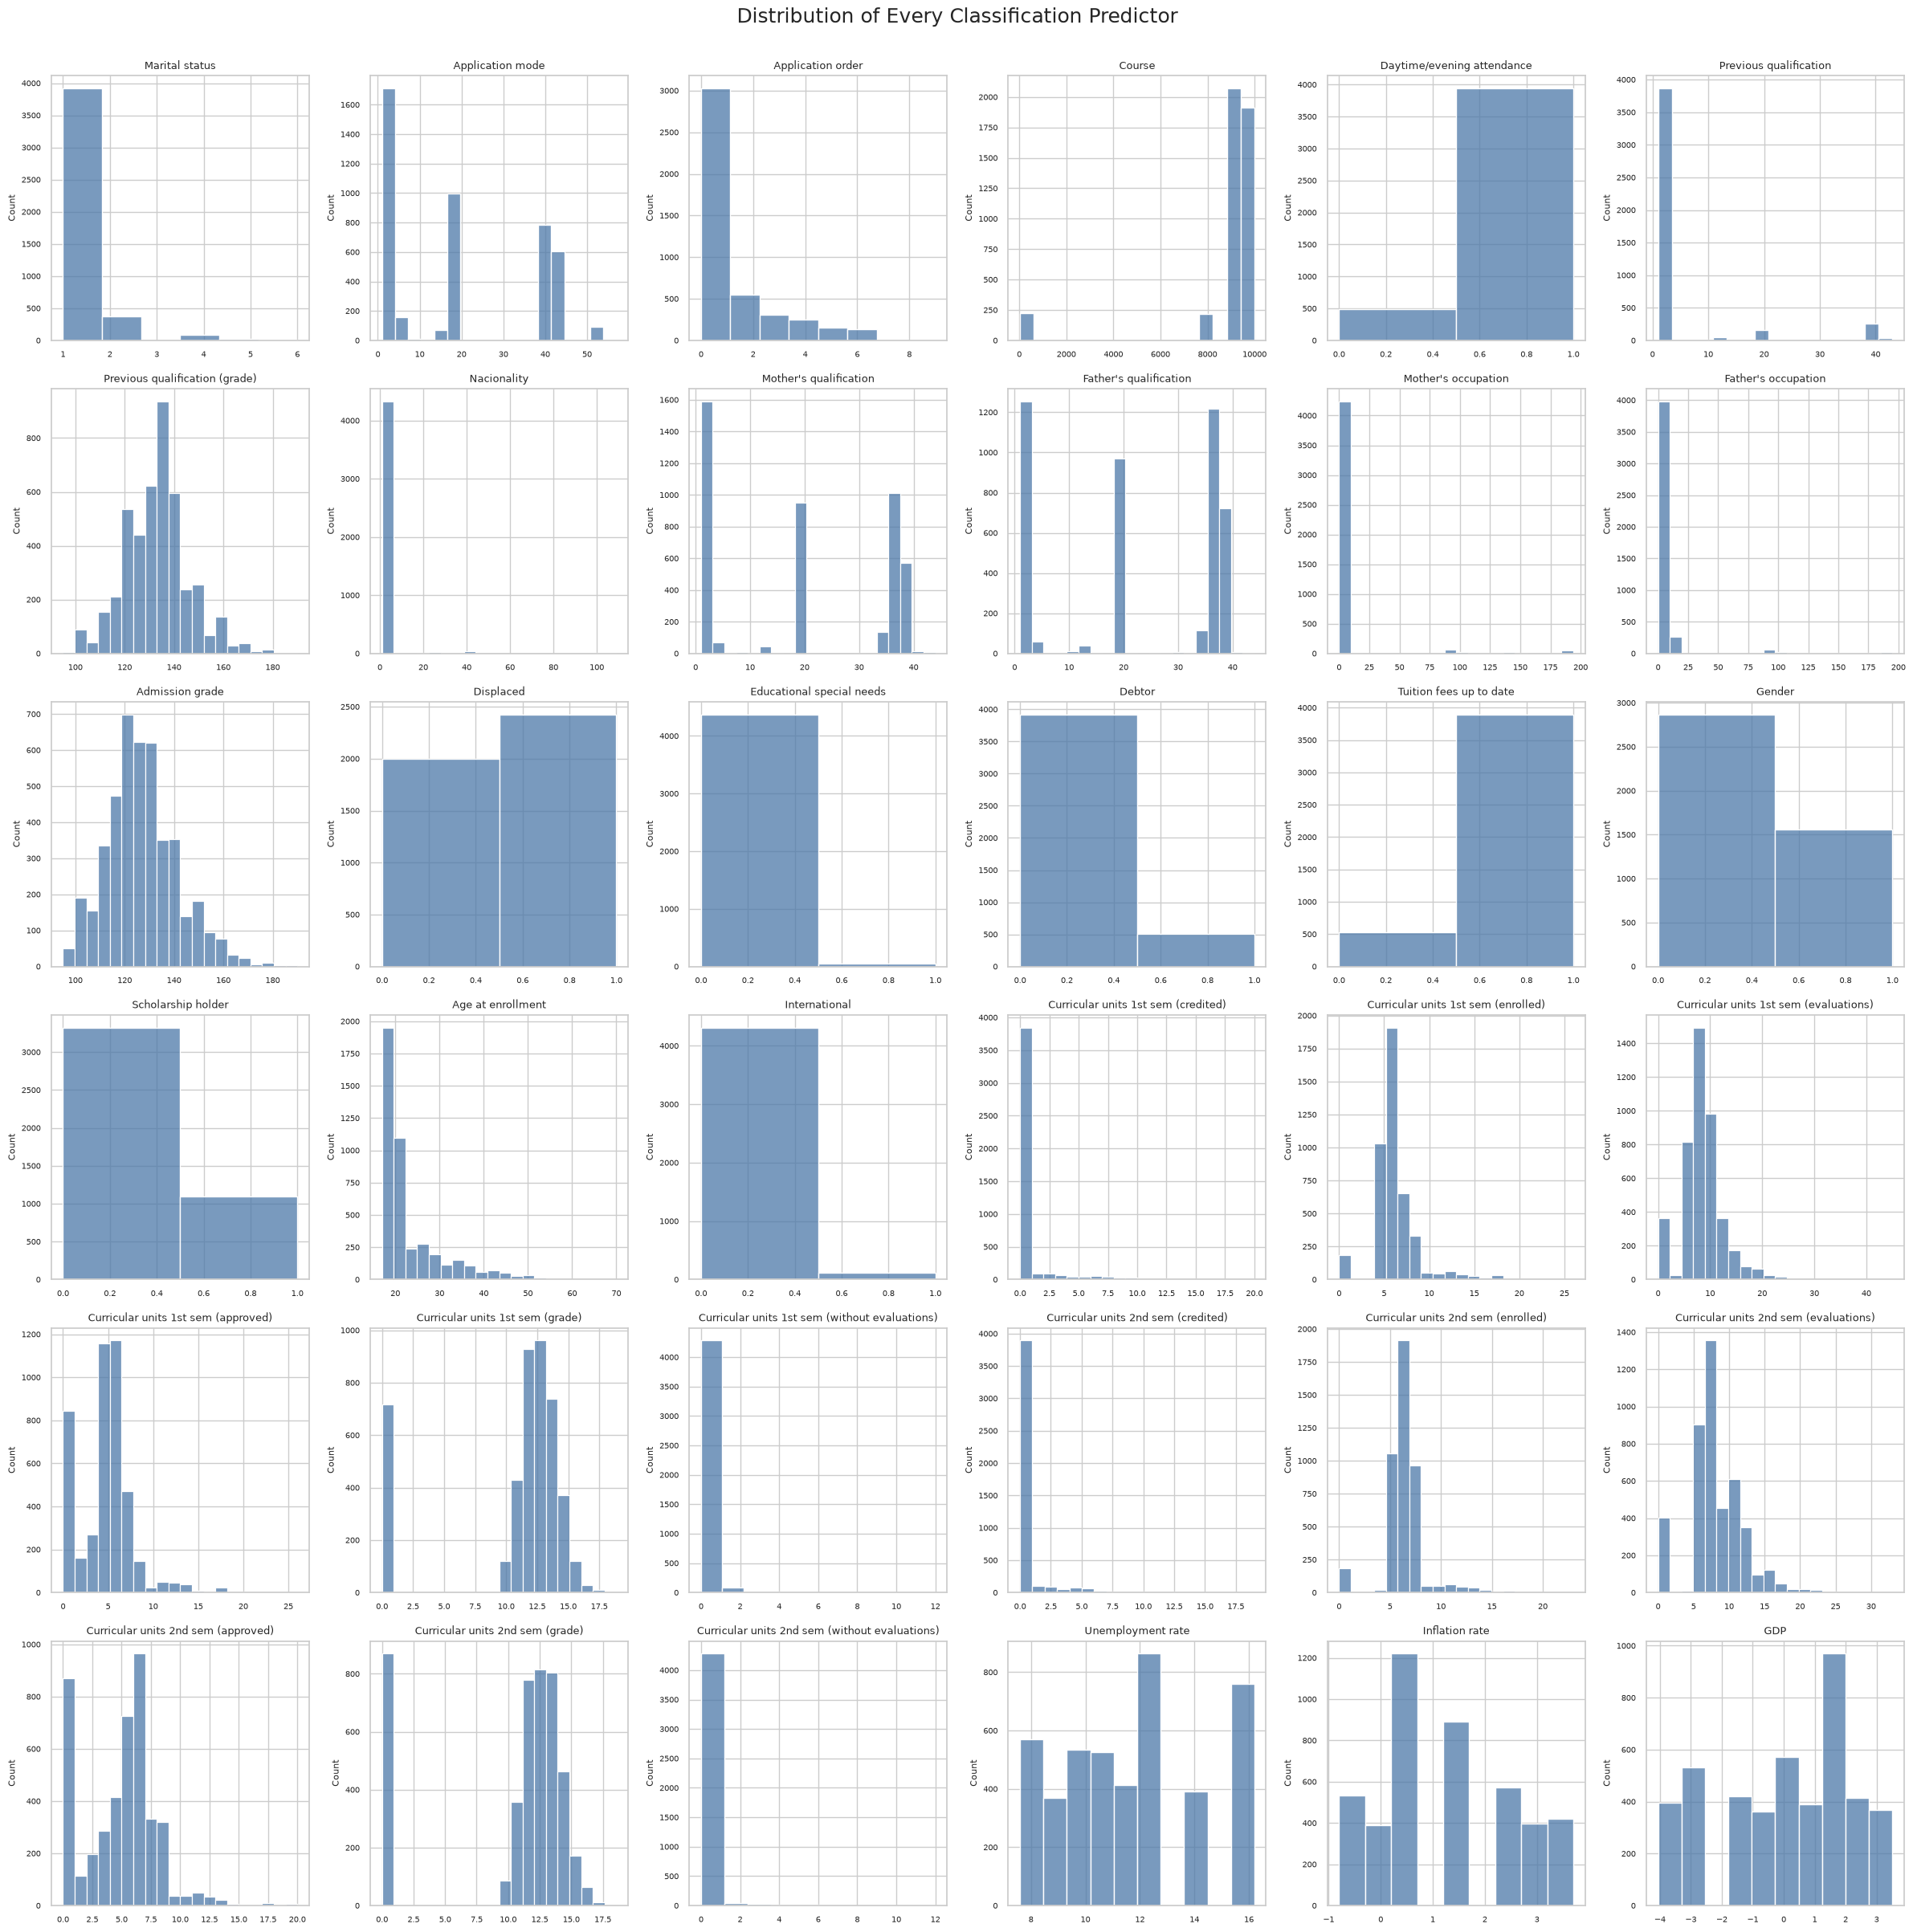

In [5]:
fig, axes = plt.subplots(6, 6, figsize=(24, 24))
for axis, column in zip(axes.flat, PREDICTORS, strict=True):
    values = raw[column]
    bins = min(20, max(2, values.nunique()))
    sns.histplot(values, bins=bins, ax=axis, color="#4C78A8")
    axis.set_title(column, fontsize=9)
    axis.set_xlabel("")
    axis.set_ylabel("Count", fontsize=8)
    axis.tick_params(axis="both", labelsize=7)
fig.suptitle("Distribution of Every Classification Predictor", fontsize=18, y=1.002)
plt.tight_layout()
plt.show()

**Observation:** Several curricular-unit variables are zero-inflated, while many administrative fields have discrete code patterns. These plots are frequency audits, not evidence that category codes have ordinal distance. The preprocessing contract therefore one-hot encodes declared categoricals and scales only genuinely numeric measures.

## 5. Numeric association audit

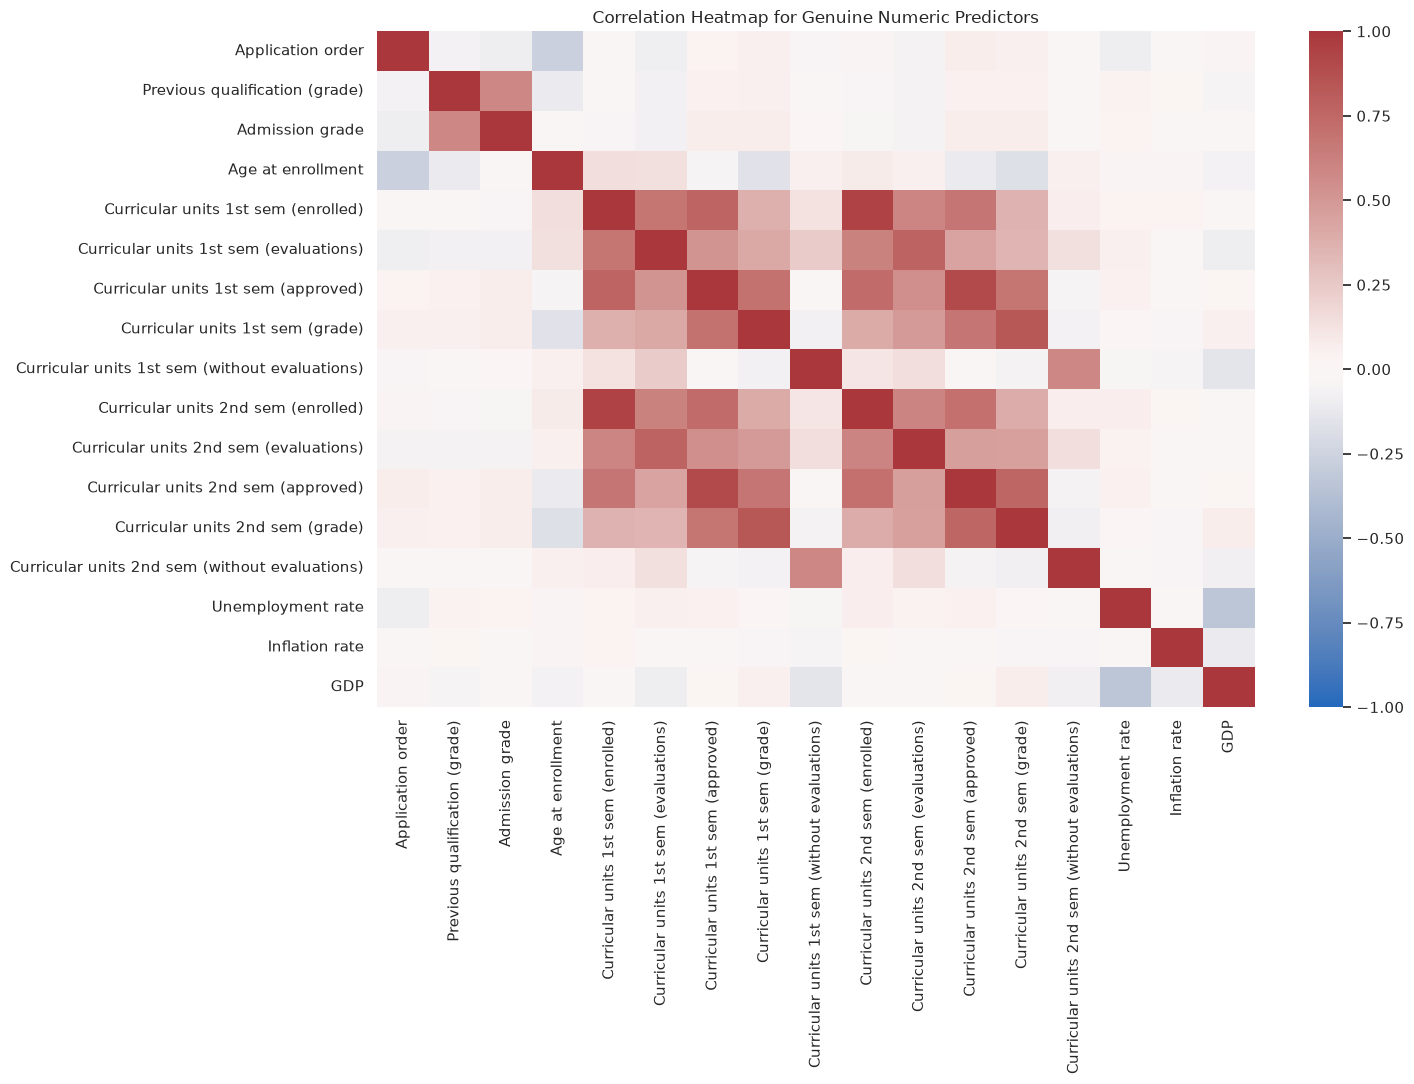

In [6]:
NUMERIC_FOR_CORRELATION = [
    "Application order",
    "Previous qualification (grade)",
    "Admission grade",
    "Age at enrollment",
    "Curricular units 1st sem (enrolled)",
    "Curricular units 1st sem (evaluations)",
    "Curricular units 1st sem (approved)",
    "Curricular units 1st sem (grade)",
    "Curricular units 1st sem (without evaluations)",
    "Curricular units 2nd sem (enrolled)",
    "Curricular units 2nd sem (evaluations)",
    "Curricular units 2nd sem (approved)",
    "Curricular units 2nd sem (grade)",
    "Curricular units 2nd sem (without evaluations)",
    "Unemployment rate",
    "Inflation rate",
    "GDP",
]
corr = raw[NUMERIC_FOR_CORRELATION].corr()
plt.figure(figsize=(15, 11))
sns.heatmap(corr, cmap="vlag", center=0, vmin=-1, vmax=1)
plt.title("Correlation Heatmap for Genuine Numeric Predictors")
plt.tight_layout()
plt.show()

**Observation:** Enrollment, evaluation, approval, and grade counts within each semester are related, but they measure different stages of academic progress. The heatmap intentionally excludes integer-coded nominal categories because Pearson correlation on arbitrary category numbers would be misleading.

## 6. Feature-target relationships

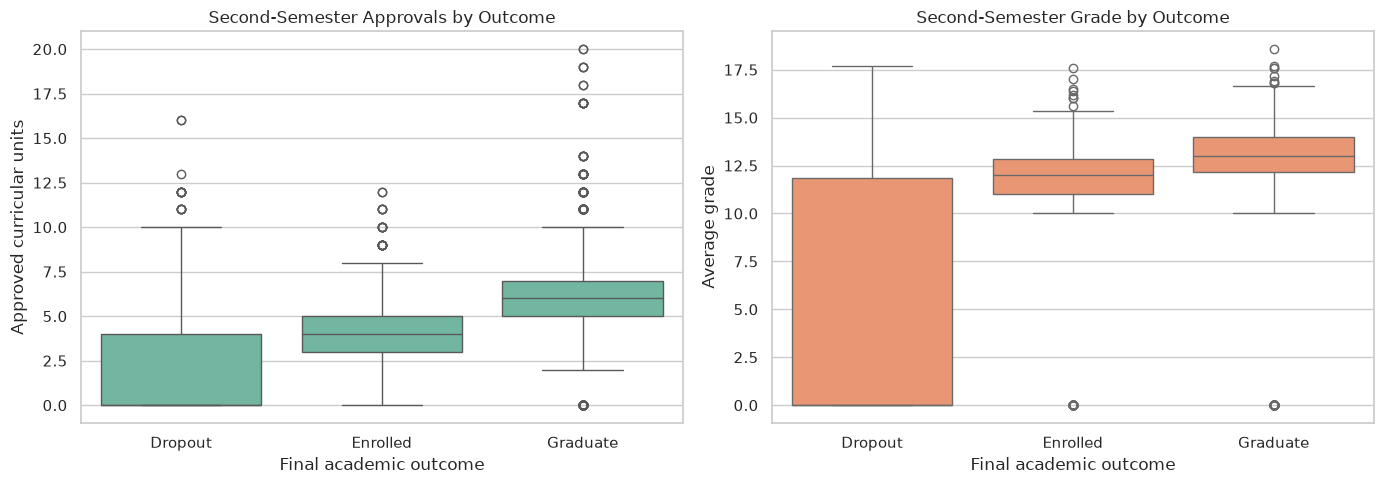

In [7]:
class_order = ["Dropout", "Enrolled", "Graduate"]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(
    data=raw,
    x=TARGET,
    y="Curricular units 2nd sem (approved)",
    order=class_order,
    color="#66C2A5",
    ax=axes[0],
)
axes[0].set_title("Second-Semester Approvals by Outcome")
axes[0].set_xlabel("Final academic outcome")
axes[0].set_ylabel("Approved curricular units")
sns.boxplot(
    data=raw,
    x=TARGET,
    y="Curricular units 2nd sem (grade)",
    order=class_order,
    color="#FC8D62",
    ax=axes[1],
)
axes[1].set_title("Second-Semester Grade by Outcome")
axes[1].set_xlabel("Final academic outcome")
axes[1].set_ylabel("Average grade")
plt.tight_layout()
plt.show()

**Observation:** Graduates generally have more approved second-semester units and higher grades, whereas zero approvals and zero grades occur more often among dropouts. The class distributions still overlap, so neither feature can decide the outcome alone. These are predictive associations measured after semester two, not causal explanations of student success.

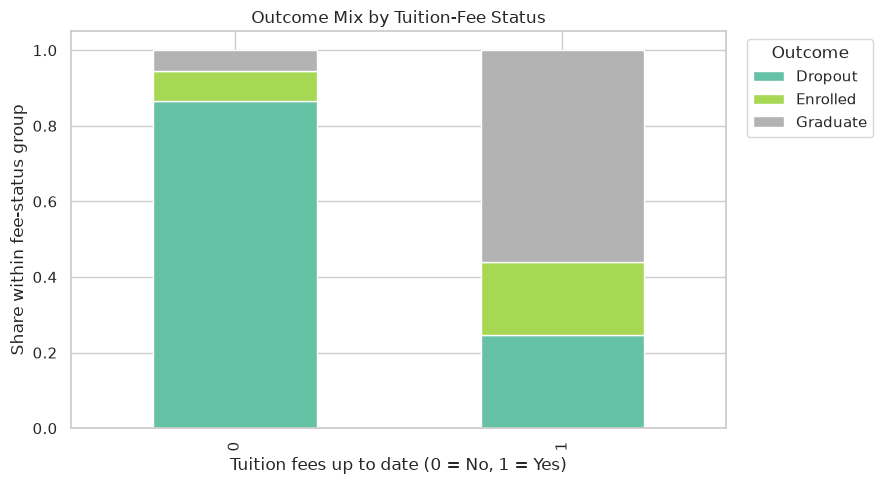

In [8]:
approval_table = pd.crosstab(
    raw["Tuition fees up to date"], raw[TARGET], normalize="index"
).reindex(columns=class_order)
approval_table.plot(kind="bar", stacked=True, figsize=(9, 5), colormap="Set2")
plt.title("Outcome Mix by Tuition-Fee Status")
plt.xlabel("Tuition fees up to date (0 = No, 1 = Yes)")
plt.ylabel("Share within fee-status group")
plt.legend(title="Outcome", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

**Observation:** The outcome mix differs visibly by fee-status group, making financial status potentially useful for support-oriented prediction. It must not be interpreted as proof that fee status causes dropout, and model outputs must not be used for automated punitive decisions.

## 7. Outlier audit

In [9]:
def iqr_audit(frame: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    records = []
    for column in columns:
        q1, q3 = frame[column].quantile([0.25, 0.75])
        iqr = q3 - q1
        lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        flagged = frame[column].lt(lower) | frame[column].gt(upper)
        records.append(
            {
                "feature": column,
                "lower_fence": lower,
                "upper_fence": upper,
                "flagged_rows": int(flagged.sum()),
                "flagged_share_pct": 100 * flagged.mean(),
                "observed_min": frame[column].min(),
                "observed_max": frame[column].max(),
            }
        )
    return pd.DataFrame(records).set_index("feature")

student_outlier_audit = iqr_audit(raw, NUMERIC_FOR_CORRELATION)
display(student_outlier_audit.sort_values("flagged_share_pct", ascending=False))

,lower_fence,upper_fence,flagged_rows,flagged_share_pct,observed_min,observed_max
feature,,,,,,
Curricular units 2nd sem (grade),6.8750,17.2083,877,19.8237,0.0000,18.5714
Curricular units 1st sem (grade),7.4000,17.0000,726,16.4105,0.0000,18.8750
Application order,-0.5000,3.5000,541,12.2288,0.0000,9.0000
Age at enrollment,10.0000,34.0000,441,9.9684,17.0000,70.0000
Curricular units 1st sem (enrolled),2.0000,10.0000,424,9.5841,0.0000,26.0000
Curricular units 2nd sem (enrolled),2.0000,10.0000,369,8.3409,0.0000,23.0000
Curricular units 1st sem (without evaluations),0.0000,0.0000,294,6.6456,0.0000,12.0000
Curricular units 2nd sem (without evaluations),0.0000,0.0000,282,6.3743,0.0000,12.0000
Curricular units 1st sem (approved),-1.5000,10.5000,180,4.0687,0.0000,26.0000


**Decision:** Phase 2 does not delete students solely for crossing an IQR fence. Rare ages, grades, and study histories may be legitimate and are part of the population the support model should understand. Categorical codes are excluded from the outlier calculation because a rare category is not a numeric outlier. Scaling and imputation remain inside the model pipeline.

## Phase 2 audit milestone

The dataset audit and EDA are complete in this milestone. Cleaning, deterministic feature engineering, the fixed stratified split, and the leakage-safe preprocessing contract are added in the next Phase 2 milestone.